# Module 10: Time Series


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image
import warnings
warnings.filterwarnings('ignore')

## Introduction

Time series data is essential for analyzing phenomena that change over time, such as weather, financial markets, or environmental measurements. In this module, you will learn how to handle dates and times in Python using the `datetime` module, work with time-indexed Pandas Series and DataFrames, and perform common operations such as resampling, aggregation, and slicing by time. By the end of this module, you will be able to organize, manipulate, and analyze temporal data using Pandas.

## Learning Objectives

- Understand and use Python's `datetime` module to work with dates and times.
- Work with time-indexed Series and DataFrames in Pandas for easy selection and slicing.
- Apply resampling techniques to aggregate or transform time series data at different frequencies.

## Reading
- [Chapter 11](https://wesmckinney.com/book/time-series)

## Datetime module

Time series data is an important form of structured data in many different fields, such as finance, economics, ecology, neuroscience, and physics. Anything that is observed or measured at many points in time forms a time series. Many time series are fixed frequency, which is to say that data points occur at regular intervals according to some rule, such as every 15 seconds, every 5 minutes, or once per month. Time series can also be irregular without a fixed unit of time or offset between units. How you mark and refer to time series data depends on the application, and you may have one of the following:

- Timestamps, specific instants in time
- Fixed periods, such as the month January 2007 or the full year 2010
- Intervals of time, indicated by a start and end timestamp. Periods can be thought of as special cases of intervals
- Experiment or elapsed time; each timestamp is a measure of time relative to a particular start time (e.g., the diameter of a cookie baking each second since being placed in the oven)

The Python standard library includes data types for date and time data, as well as calendar-related functionality. The **datetime**, **time**, and **calendar** modules are the main places to start.

1. Classes in datetime module

|Class| Description|
|----|------------|
|date| Store calendar date (year, month, day) using the Gregorian calendar|
|time| Store time of day as hours, minutes, seconds, and microseconds|
|datetime| Stores both date and time|
|timedelta| Represents the difference between two datetime values (as days, seconds, and microseconds)|
|tzinfo| Base type for storing time zone information|


In [2]:
from datetime import datetime, timedelta, date

now = datetime.now()
now

datetime.datetime(2026, 3, 21, 23, 0, 41, 184218)

In [3]:
now.year, now.month, now.day, now.hour, now.minute, now.second

(2026, 3, 21, 23, 0, 41)

You can create a datetime object by specifying the year, month, day, hour, minute and/or second:

In [4]:
date = datetime(year=2022,month=11,day=2,hour=12)
date

datetime.datetime(2022, 11, 2, 12, 0)

**timedelta** represents the temporal difference between two datetime objects:

In [5]:
delta = datetime(2022,11,10) - datetime(2022,11,9,12)
delta

datetime.timedelta(seconds=43200)

In [6]:
from datetime import timedelta

t1 = datetime(2022,11,10)
t2 = t1 + timedelta(days=1,hours=3)
#t2 = t1 + timedelta(hours=27)

t2

datetime.datetime(2022, 11, 11, 3, 0)

You can format datetime objects and pandas Timestamp objects (introduced later) as strings using the **strftime()** method, passing a format specification.

There are two useful datetime methods to deal with conversion from string to datetime, and vice versa.

- **datetime.strftime(format)**: Return a string representing the date, controlled by an explicit format string. You can format datetime objects and pandas Timestamp objects (introduced later) as strings using the strftime method, passing a format specification
- **datetime.strptime(date_string, format)**: Return a datetime corresponding to date_string, parsed according to format.

List of datetime format specification

|Type| Description|
|----|------------|
|%Y| Four-digit year|
|%y| Two-digit year|
|%m| Two-digit month [01, 12]|
|%d| Two-digit day [01, 31]|
|%H| Hour (24-hour clock) [00, 23]|
|%I| Hour (12-hour clock) [01, 12]|
|%M| Two-digit minute [00, 59]|
|%S| Second [00, 61] (seconds 60, 61 account for leap seconds)|
|%w| Weekday as integer [0 (Sunday), 6]|
|%U| Week number of the year [00, 53]; Sunday is considered the first day of the week, and days before the first Sunday of the year are “week 0”|
|%W| Week number of the year [00, 53]; Monday is considered the first day of the week, and days before the first Monday of the year are “week 0”
|%z| UTC time zone offset as +HHMM or -HHMM; empty if time zone naive|
|%F| Shortcut for %Y-%m-%d (e.g., 2012-4-18)|
|%D| Shortcut for %m/%d/%y (e.g., 04/18/12)|
|%a| Weekday as locale’s abbreviated name (e.g., Sun, Mon, ...)|
|%A| Weekday as locale’s full name (e.g., Sunday, Monday, ...)|
|%b| Month as locale’s abbreviated name (e.g., Jan, Feb, ...|
|%B| Month as locale’s full name (e.g., January, Feburary, ...)|
|%p| Locale’s equivalent of either AM or PM|

In [7]:
now = datetime.now()
now.strftime('Current time is %Y-%m-%d %H:%M:%S')

'Current time is 2026-03-21 23:00:41'

In [8]:
now.strftime('Current time is %H:%M on %A, %B %d %Y')

'Current time is 23:00 on Saturday, March 21 2026'

In [9]:
date_string = '2022 11-10 12:30 AM'
datetime.strptime(date_string,'%Y %m-%d %H:%M %p')

datetime.datetime(2022, 11, 10, 12, 30)

pandas is generally oriented toward working with arrays of dates, whether used as an axis index or a column in a DataFrame. The **to_datetime** method parses many different kinds of date representations.

In [10]:
datestrs = ['11/6/2022 01:00:00', '11/6/2022 03:00:00', '11/6/2022 06:00:00']
pd.to_datetime(datestrs)


DatetimeIndex(['2022-11-06 01:00:00', '2022-11-06 03:00:00',
               '2022-11-06 06:00:00'],
              dtype='datetime64[ns]', freq=None)

The **pd.date_range()** method is useful for generating a range of range of equally spaced time points (where the difference between any two adjacent points is specified by the given frequency).

Base time series frequencies:

|Alias| Offset type| Description|
|-----|------------|------------|
|D| Day| Calendar daily|
|B| BusinessDay| Business daily|
|H| Hour| Hourly|
|T or min| Minute| Minutely|
|S| Second| Secondly|
|L or ms| Milli| Millisecond (1/1,000 of 1 second)|
|U| Micro| Microsecond (1/1,000,000 of 1 second)|
|M| MonthEnd| Last calendar day of month|
|BM| BusinessMonthEnd| Last business day (weekday) of month|
|MS| MonthBegin| First calendar day of month|
|BMS| BusinessMonthBegin| First weekday of month|
|W-MON, W-TUE, ...| Week| Weekly on given day of week (MON, TUE, WED, THU, FRI, SAT, or SUN)|
|WOM-1MON, WOM-2MON, ...| WeekOfMonth| Generate weekly dates in the first, second, third, or fourth week of the month (e.g., WOM-3FRI for the third Friday of each month)|
|Q-JAN, Q-FEB, ...| QuarterEnd| Quarterly dates anchored on last calendar day of each month, for year ending in indicated month (JAN, FEB, MAR, APR, MAY, JUN, JUL, AUG, SEP, OCT, NOV, or DEC)|
|BQ-JAN, BQ-FEB, ...| BusinessQuarterEnd| Quarterly dates anchored on last weekday day of each month, for year ending in indicated month|
|QS-JAN, QS-FEB, ...| QuarterBegin| Quarterly dates anchored on first calendar day of each month, for year ending in indicated month|
|BQS-JAN, BQS-FEB, ...| BusinessQuarterBegin| Quarterly dates anchored on first weekday day of each month, for year ending in indicated month|
|A-JAN, A-FEB, ...| YearEnd| Annual dates anchored on last calendar day of given month (JAN, FEB, MAR, APR, MAY, JUN, JUL, AUG, SEP, OCT, NOV, or DEC)|
|BA-JAN, BA-FEB, ...| BusinessYearEnd| Annual dates anchored on last weekday of given month|
|AS-JAN, AS-FEB, ...| YearBegin| Annual dates anchored on first day of given month|
|BAS-JAN, BAS-FEB, ...| BusinessYearBegin| Annual dates anchored on first weekday of given month|

In [11]:
pd.date_range(start='2022/1/1',end='2022/12/1',freq='M')

DatetimeIndex(['2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
               '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31',
               '2022-09-30', '2022-10-31', '2022-11-30'],
              dtype='datetime64[ns]', freq='ME')

In [12]:
pd.date_range(start='2022/1/1',end='2022/12/1',freq='MS')

DatetimeIndex(['2022-01-01', '2022-02-01', '2022-03-01', '2022-04-01',
               '2022-05-01', '2022-06-01', '2022-07-01', '2022-08-01',
               '2022-09-01', '2022-10-01', '2022-11-01', '2022-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [13]:
pd.date_range(start='2000',end='2023',freq='AS')

DatetimeIndex(['2000-01-01', '2001-01-01', '2002-01-01', '2003-01-01',
               '2004-01-01', '2005-01-01', '2006-01-01', '2007-01-01',
               '2008-01-01', '2009-01-01', '2010-01-01', '2011-01-01',
               '2012-01-01', '2013-01-01', '2014-01-01', '2015-01-01',
               '2016-01-01', '2017-01-01', '2018-01-01', '2019-01-01',
               '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01'],
              dtype='datetime64[ns]', freq='YS-JAN')

In [14]:
pd.date_range(start='2022/11/10 00',periods=12,freq='h')

DatetimeIndex(['2022-11-10 00:00:00', '2022-11-10 01:00:00',
               '2022-11-10 02:00:00', '2022-11-10 03:00:00',
               '2022-11-10 04:00:00', '2022-11-10 05:00:00',
               '2022-11-10 06:00:00', '2022-11-10 07:00:00',
               '2022-11-10 08:00:00', '2022-11-10 09:00:00',
               '2022-11-10 10:00:00', '2022-11-10 11:00:00'],
              dtype='datetime64[ns]', freq='h')

In [15]:
pd.date_range(end='2022/11/10 00',periods=12,freq='h')

DatetimeIndex(['2022-11-09 13:00:00', '2022-11-09 14:00:00',
               '2022-11-09 15:00:00', '2022-11-09 16:00:00',
               '2022-11-09 17:00:00', '2022-11-09 18:00:00',
               '2022-11-09 19:00:00', '2022-11-09 20:00:00',
               '2022-11-09 21:00:00', '2022-11-09 22:00:00',
               '2022-11-09 23:00:00', '2022-11-10 00:00:00'],
              dtype='datetime64[ns]', freq='h')

In [16]:
pd.date_range(end='2022/11/10',periods=12,freq='3D')

DatetimeIndex(['2022-10-08', '2022-10-11', '2022-10-14', '2022-10-17',
               '2022-10-20', '2022-10-23', '2022-10-26', '2022-10-29',
               '2022-11-01', '2022-11-04', '2022-11-07', '2022-11-10'],
              dtype='datetime64[ns]', freq='3D')

## Resampling

**Resampling** refers to the process of converting a time series from one frequency to another.

Pandas objects are equipped with a resample method, which is the workhorse function for all frequency conversion. **resample()** has a similar API to **groupby()**; You call resample to group the data, then call an aggregation function.

Below we will use stock price data to show how resampling works.

In [17]:
# use read_csv to read in historical stock price of Google, Inc.
# The first column is parsed as DatetimeIndex type and the index of the DataFrame by setting index_col=0.
goog = pd.read_csv('data/goog.csv',header=0,parse_dates=[0],index_col=0)
goog.sort_index(inplace=True)
goog

,Close/Last,Volume,Open,High,Low
Date,,,,,
2014-03-27,$558.46,13052,$568,$568,$552.92
2014-03-28,$559.99,41003,$561.2,$566.43,$558.67
2014-03-31,$556.97,10772,$566.89,$567,$556.93
2014-04-01,$567.16,7932,$558.71,$568.45,$558.71
2014-04-02,$567,146697,$599.99,$604.83,$562.19
...,...,...,...,...,...
2021-11-01,$2875.48,1613605,$2963.3,$2967.99,$2871.59
2021-11-02,$2917.26,1057529,$2896.188,$2938.41,$2892.82
2021-11-03,$2935.8,894330,$2925.5,$2938.21,$2901.07


In [18]:
goog.dtypes

Close/Last    object
Volume         int64
Open          object
High          object
Low           object
dtype: object

Notice that the 'Close/Last', 'Open', 'High', and 'Low' columns are not float, and the numeric values have dollar signs before them. We need to convert the currency to float.

In [19]:
goog['Close/Last'] = goog['Close/Last'].str.replace('$', '').astype('float')
goog['Open'] = goog['Open'].str.replace('$', '').astype('float')
goog['High'] = goog['High'].str.replace('$', '').astype('float')
goog['Low'] = goog['Low'].str.replace('$', '').astype('float')
goog['Volume'] = goog['Volume'].astype('float')
goog

,Close/Last,Volume,Open,High,Low
Date,,,,,
2014-03-27,558.46,13052.0,568.000,568.0000,552.92
2014-03-28,559.99,41003.0,561.200,566.4300,558.67
2014-03-31,556.97,10772.0,566.890,567.0000,556.93
2014-04-01,567.16,7932.0,558.710,568.4500,558.71
2014-04-02,567.00,146697.0,599.990,604.8300,562.19
...,...,...,...,...,...
2021-11-01,2875.48,1613605.0,2963.300,2967.9900,2871.59
2021-11-02,2917.26,1057529.0,2896.188,2938.4100,2892.82
2021-11-03,2935.80,894330.0,2925.500,2938.2100,2901.07


In [20]:
goog.dtypes

Close/Last    float64
Volume        float64
Open          float64
High          float64
Low           float64
dtype: object

After sorting the index (by calling sort_index), the time series data is ordered chronologically. Then you can slice the DataFrame with timestamps not contained in a time series to perform a range query. You can pass either a string date, datetime, or timestamp. Remember that slicing in this manner produces views (shallow copy) on the source time series. 

In [21]:
# Slice data for 2015
goog.loc['2015']

,Close/Last,Volume,Open,High,Low
Date,,,,,
2015-01-02,524.81,1444809.0,529.01,531.270,524.10
2015-01-05,513.87,2049303.0,523.26,524.330,513.06
2015-01-06,501.96,2884479.0,515.00,516.175,501.05
2015-01-07,501.10,2053750.0,507.00,507.244,499.65
2015-01-08,502.68,3341935.0,497.99,503.480,491.00
...,...,...,...,...,...
2015-12-24,748.40,527223.0,749.55,751.350,746.62
2015-12-28,762.51,1515574.0,752.92,762.990,749.52
2015-12-29,776.60,1764044.0,766.69,779.980,766.43


In [22]:
# Slice data between 2015 and 2016
goog.loc['2015':'2016']

,Close/Last,Volume,Open,High,Low
Date,,,,,
2015-01-02,524.81,1444809.0,529.01,531.270,524.100
2015-01-05,513.87,2049303.0,523.26,524.330,513.060
2015-01-06,501.96,2884479.0,515.00,516.175,501.050
2015-01-07,501.10,2053750.0,507.00,507.244,499.650
2015-01-08,502.68,3341935.0,497.99,503.480,491.000
...,...,...,...,...,...
2016-12-23,789.91,623682.0,790.90,792.740,787.280
2016-12-27,791.55,789151.0,790.68,797.860,787.657
2016-12-28,785.05,1142148.0,793.70,794.230,783.200


In [23]:
# Slice data between two specific dates
goog.loc['2015-2-20':'2015-7-1']

,Close/Last,Volume,Open,High,Low
Date,,,,,
2015-02-20,538.95,1441147.0,543.13,543.750,535.8000
2015-02-23,531.91,1453049.0,536.05,536.439,529.4100
2015-02-24,536.09,1002313.0,530.00,536.790,528.2500
2015-02-25,543.87,1820199.0,535.90,546.220,535.4450
2015-02-26,555.48,2303785.0,543.21,556.140,541.5000
...,...,...,...,...,...
2015-06-25,535.23,1332412.0,538.87,540.900,535.2300
2015-06-26,531.69,2108629.0,537.26,537.760,531.3500
2015-06-29,521.52,1935361.0,525.01,528.610,520.5400


In [24]:
# Using a different date format
goog.loc['12/1/2015':'5/15/2016']

,Close/Last,Volume,Open,High,Low
Date,,,,,
2015-12-01,767.04,2131827.0,747.11,768.9500,746.70
2015-12-02,762.38,2196721.0,768.90,775.9550,758.96
2015-12-03,752.54,2589641.0,766.01,768.9950,745.63
2015-12-04,766.81,2756194.0,753.10,768.4900,750.00
2015-12-07,763.25,1811336.0,767.77,768.7300,755.09
...,...,...,...,...,...
2016-05-09,712.90,1509892.0,712.00,718.7100,710.00
2016-05-10,723.18,1568621.0,716.75,723.5000,715.72
2016-05-11,715.29,1690862.0,723.41,724.4800,712.80


How do you calculate the monthly average of goog? 

We can use the **resampling** method. Resampling works in a similar way to groupby.

In [25]:
# If you do not specify any columns, aggregation will be performed on all columns.
goog.resample('ME').mean()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2014-03-31,558.473333,2.160900e+04,565.363333,567.143333,556.173333
2014-04-30,540.028571,3.189996e+06,543.970476,549.592381,533.041957
2014-05-31,534.053333,1.736266e+06,533.136190,537.571552,528.415857
2014-06-30,558.430476,1.803118e+06,557.843810,561.528857,552.762933
2014-07-31,584.015677,1.566331e+06,584.146818,587.762845,579.376905
...,...,...,...,...,...
2021-07-31,2646.785714,1.087641e+06,2641.907476,2663.623214,2624.577457
2021-08-31,2786.406818,8.462950e+05,2776.401364,2797.319168,2762.866755
2021-09-30,2837.638095,1.203125e+06,2847.702762,2864.327690,2819.896771


In [26]:
goog.resample('MS').mean()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2014-03-01,558.473333,2.160900e+04,565.363333,567.143333,556.173333
2014-04-01,540.028571,3.189996e+06,543.970476,549.592381,533.041957
2014-05-01,534.053333,1.736266e+06,533.136190,537.571552,528.415857
2014-06-01,558.430476,1.803118e+06,557.843810,561.528857,552.762933
2014-07-01,584.015677,1.566331e+06,584.146818,587.762845,579.376905
...,...,...,...,...,...
2021-07-01,2646.785714,1.087641e+06,2641.907476,2663.623214,2624.577457
2021-08-01,2786.406818,8.462950e+05,2776.401364,2797.319168,2762.866755
2021-09-01,2837.638095,1.203125e+06,2847.702762,2864.327690,2819.896771


In [27]:
goog.resample('ME',kind='period').mean()

,Close/Last,Volume,Open,High,Low
Date,,,,,
2014-03,558.473333,2.160900e+04,565.363333,567.143333,556.173333
2014-04,540.028571,3.189996e+06,543.970476,549.592381,533.041957
2014-05,534.053333,1.736266e+06,533.136190,537.571552,528.415857
2014-06,558.430476,1.803118e+06,557.843810,561.528857,552.762933
2014-07,584.015677,1.566331e+06,584.146818,587.762845,579.376905
...,...,...,...,...,...
2021-07,2646.785714,1.087641e+06,2641.907476,2663.623214,2624.577457
2021-08,2786.406818,8.462950e+05,2776.401364,2797.319168,2762.866755
2021-09,2837.638095,1.203125e+06,2847.702762,2864.327690,2819.896771


Similar to groupby, resample can work with the aggregation operation, and apply different functions to each column

In [28]:
goog.resample('ME',kind='period').agg({'Close/Last':'mean','Volume':'sum'})

,Close/Last,Volume
Date,,
2014-03,558.473333,64827.0
2014-04,540.028571,66989907.0
2014-05,534.053333,36461579.0
2014-06,558.430476,37865472.0
2014-07,584.015677,34459273.0
...,...,...
2021-07,2646.785714,22840459.0
2021-08,2786.406818,18618490.0
2021-09,2837.638095,25265626.0


Resample is a flexible and high-performance method that can be used to process very large time series.

Resample method arguments:

|Argument| Description|
|--------|------------|
|freq| String or DateOffset indicating desired resampled frequency (e.g., ‘M', ’5min', or Second(15))|
|axis| Axis to resample on; default axis=0|
|fill_method| How to interpolate when upsampling, as in 'ffill' or 'bfill'; by default does no interpolation|
|closed| In downsampling, which end of each interval is closed (inclusive), 'right' or 'left'|
|label| In downsampling, how to label the aggregated result, with the 'right' or 'left' bin edge (e.g., the 9:30 to 9:35 five-minute interval could be labeled 9:30 or 9:35)|
|loffset| Time adjustment to the bin labels, such as '-1s' / Second(-1) to shift the aggregate labels one second earlier|
|limit| When forward or backward filling, the maximum number of periods to fill|
|kind| Aggregate to periods ('period') or timestamps ('timestamp'); defaults to the type of index the time series has|
|convention| When resampling periods, the convention ('start' or 'end') for converting the low-frequency period to high frequency; defaults to 'end'|


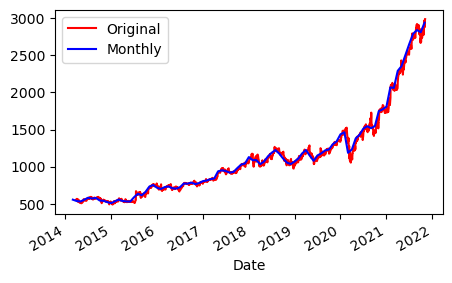

In [29]:
goog['Close/Last'].plot(c='r',figsize=(5,3),label='Original')
goog['Close/Last'].resample('ME',kind='period').mean().plot(c='b',label='Monthly')
plt.legend()

In [30]:
# read in the historical stock price of Apple, Inc.
aapl = pd.read_csv('data/aapl.csv',header=0,parse_dates=[0],index_col=0)
aapl.sort_index(inplace=True)
aapl['Close/Last'] = aapl['Close/Last'].str.replace('$', '').astype('float')
aapl['Open'] = aapl['Open'].str.replace('$', '').astype('float')
aapl['High'] = aapl['High'].str.replace('$', '').astype('float')
aapl['Low'] = aapl['Low'].str.replace('$', '').astype('float')
aapl['Volume'] = aapl['Volume'].astype('float')
aapl

,Close/Last,Volume,Open,High,Low
Date,,,,,
2011-11-07,14.2761,269645380.0,14.2825,14.2857,14.1475
2011-11-08,14.5082,399592880.0,14.3646,14.5714,14.3414
2011-11-09,14.1171,557542777.0,14.1775,14.3175,14.0796
2011-11-10,13.7579,744444382.0,14.1796,14.1861,13.6482
2011-11-11,13.7364,653277539.0,13.8075,13.8821,13.5807
...,...,...,...,...,...
2021-11-01,148.9600,74588260.0,148.9850,149.7000,147.8000
2021-11-02,150.0200,69121990.0,148.6600,151.5700,148.6500
2021-11-03,151.4900,54511530.0,150.3900,151.9700,149.8200


In [31]:
# Concatenate the Close/Last columns from two DataFrames, and rename them to 'goog' and 'aapl'
dfstock = pd.concat([goog['Close/Last'], aapl['Close/Last']], axis=1,keys=['goog','aapl'])
dfstock

,goog,aapl
Date,,
2011-11-07,NaN,14.2761
2011-11-08,NaN,14.5082
2011-11-09,NaN,14.1171
2011-11-10,NaN,13.7579
2011-11-11,NaN,13.7364
...,...,...
2021-11-01,2875.48,148.9600
2021-11-02,2917.26,150.0200
2021-11-03,2935.80,151.4900


<AxesSubplot:xlabel='Date'>

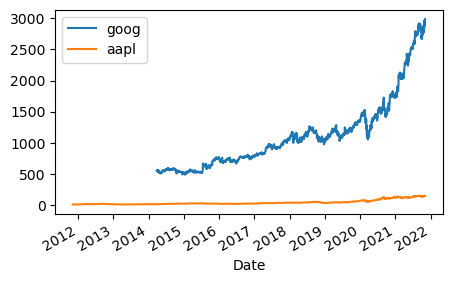

In [32]:
dfstock.plot(figsize=(5,3))

<AxesSubplot:xlabel='Date'>

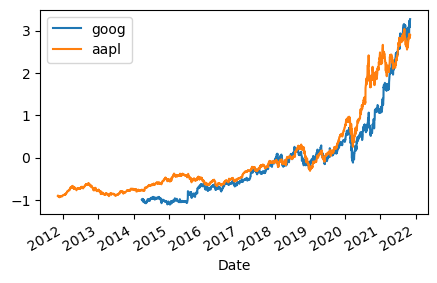

In [33]:
# The above plot does not show the co-variations of goog and appl, due to large difference in the magnitude.
# We can normalize the two time series by their respective mean and standard deviation.
dfstock = (dfstock-dfstock.mean())/dfstock.std()
dfstock.plot(figsize=(5,3))

In [34]:
# We confirm that the correlation between the goog and appl stock prices are very high (r=0.95)
dfstock.corr()

,goog,aapl
goog,1.000000,0.950588
aapl,0.950588,1.000000
